In [49]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout, LSTM
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

import shap

import numpy as np
import matplotlib.pyplot as plt
from pylab import rcParams

/opt/anaconda3/envs/AI/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%matplotlib inline

In [3]:
rcParams['figure.figsize'] = 10, 6
rcParams['lines.linewidth'] = 2
rcParams['lines.markersize'] = 6
rcParams['font.size'] = 12
rcParams["font.family"] = "Times New Roman"

In [4]:
# Load the DataFrame from the pickle file
pickle_file_path = "project_folder/Wind/Outputs/IEA15MW.pkl"
df = pd.read_pickle(pickle_file_path)

df.head()

,Time_[s],Wind1VelX_[m/s],Wind1VelY_[m/s],Wind1VelZ_[m/s],Azimuth_[deg],BldPitch1_[deg],BldPitch2_[deg],BldPitch3_[deg],GenSpeed_[rpm],LSSTipMya_[kN-m],...,M5N1FKze_[N],M5N1MKxe_[N*m],M5N1MKye_[N*m],M5N1MKze_[N*m],ReactFXss_[N],ReactFYss_[N],ReactFZss_[N],ReactMXss_[N*m],ReactMYss_[N*m],ReactMZss_[N*m]
0,5.00,22.489066,3.127790,-0.212661,213.460923,20.426280,20.426280,20.426280,7.211221,-30541.060841,...,-1.857447e+07,5.628423e+06,1.390518e+08,-9.317949e+06,-8.049700e+05,2.514650e+06,-792499.257476,-6.146387e+07,-1.820476e+08,9.315525e+06
1,5.01,22.657360,3.388776,0.011401,213.894854,20.430111,20.430111,20.430111,7.186717,-30807.118299,...,-1.854753e+07,4.912923e+06,1.380571e+08,-9.598476e+06,-8.415019e+05,2.514650e+06,-819443.884521,-6.163417e+07,-1.832149e+08,9.595547e+06
2,5.02,22.825959,3.649763,0.235654,214.323293,20.432939,20.432939,20.432939,7.166537,-30703.008859,...,-1.855619e+07,6.979922e+06,1.366953e+08,-9.880570e+06,-9.317572e+05,1.989170e+06,-809820.803433,-5.550320e+07,-1.850647e+08,9.878698e+06
3,5.03,22.994253,3.910473,0.459717,214.751732,20.435038,20.435038,20.435038,7.156087,-30251.867952,...,-1.859372e+07,1.119342e+07,1.349629e+08,-1.015326e+07,-1.076273e+06,1.084175e+06,-773253.095300,-4.460371e+07,-1.875609e+08,1.015246e+07
4,5.04,23.162547,4.171459,0.683970,215.185663,20.437045,20.437045,20.437045,7.157889,-29569.372735,...,-1.864472e+07,1.612242e+07,1.329369e+08,-1.041028e+07,-1.263768e+06,6.240633e+04,-721288.457428,-3.217147e+07,-1.905181e+08,1.041058e+07


In [5]:
# Set display options to show the full result
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# Predicte Power Generation (GenPwr)

In [6]:
df.describe()['GenPwr_[kW]']

count    40001.000000
mean     15002.390808
std      13055.297727
min      -8968.894225
25%       3832.815948
50%      14688.429759
75%      26179.047605
max      38267.189112
Name: GenPwr_[kW], dtype: float64

In [10]:
# Calculate Spearman correlation
spearman_corr = df.corr(method='spearman')['GenPwr_[kW]'].sort_values(ascending=False)
print("\nSpearman Correlation with GenPwr_[kW]:")
print(spearman_corr)


Spearman Correlation with GenPwr_[kW]:
GenPwr_[kW]            1.000000
GenSpeed_[rpm]         1.000000
RotSpeed_[rpm]         1.000000
TwHt1MLxt_[kN-m]       0.854049
PtfmSway_[m]           0.539335
YawBrFxp_[kN]          0.337350
TwHt9FLxt_[kN]         0.270276
NcIMUTAzs_[m/s^2]      0.211919
TwrBsMxt_[kN-m]        0.177575
M3N1FKye_[N]           0.151262
ReactFXss_[N]          0.146286
M5N1MKxe_[N*m]         0.145657
LSShftFxa_[kN]         0.133105
LSShftFxs_[kN]         0.133105
RotThrust_[kN]         0.133105
TwrBsFxt_[kN]          0.128469
TwHt8FLxt_[kN]         0.125869
TwHt1FLxt_[kN]         0.120398
NcIMUTAxs_[m/s^2]      0.116285
TwHt2MLxt_[kN-m]       0.113443
ReactFZss_[N]          0.111916
ReactMXss_[N*m]        0.102606
M4N1FKxe_[N]           0.097428
M5N1FKxe_[N]           0.097427
TwHt2FLxt_[kN]         0.092155
M2N1FKye_[N]           0.090062
M4N1MKye_[N*m]         0.084567
M4N1MKxe_[N*m]         0.083556
M1N1FKye_[N]           0.082217
M5N1MKye_[N*m]         0.077230


In [13]:
# Sort the correlation coefficients by their absolute values in descending order
spearman_corr_abs = spearman_corr.abs().sort_values(ascending=False)

# Select the top 10 columns based on the sorted correlation coefficients
top_3_columns = spearman_corr_abs.index[1:4]  # Exclude the target variable itself
print("Top 3 most relevant columns based on Spearman correlation (absolute value):")
print(top_3_columns)

# Display the Spearman correlation values for the top 10 columns
print("\nSpearman Correlation values for the top 10 columns:")
print(spearman_corr[top_3_columns])

Top 3 most relevant columns based on Spearman correlation (absolute value):
Index(['GenSpeed_[rpm]', 'RotSpeed_[rpm]', 'TwHt1MLxt_[kN-m]'], dtype='object')

Spearman Correlation values for the top 10 columns:
GenSpeed_[rpm]      1.000000
RotSpeed_[rpm]      1.000000
TwHt1MLxt_[kN-m]    0.854049
Name: GenPwr_[kW], dtype: float64


In [14]:
# Extract input variables (X) and output variable (y)
X = df[top_3_columns].values
y = df['GenPwr_[kW]'].values

# Perform train-test split
X_train_val, X_test, y_train_val, y_test, train_val_indices, test_indices = train_test_split(X, y, df.index, test_size=0.2, random_state=42)

# Perform train-validation split
X_train, X_val, y_train, y_val, train_indices, val_indices = train_test_split(X_train_val, y_train_val, train_val_indices, test_size=0.25, random_state=42)

In [15]:
from sklearn.preprocessing import StandardScaler

# Normalize the input data
scaler = StandardScaler()
X_train_normalized = scaler.fit_transform(X_train)
X_val_normalized = scaler.transform(X_val)
X_test_normalized = scaler.transform(X_test)

In [16]:
# Define the neural network architecture
model = Sequential([
    Input(shape=(X_train_normalized.shape[1],)),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1)
])

# Compile the model
model.compile(optimizer='adam', loss='mse')

# Train the model
history = model.fit(X_train_normalized, y_train, epochs=200, batch_size=32, validation_data=(X_val_normalized, y_val))

Epoch 1/200
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 599us/step - loss: 146402128.0000 - val_loss: 6273.8135
Epoch 2/200
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 542us/step - loss: 3947.1277 - val_loss: 1628.3914
Epoch 3/200
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 537us/step - loss: 1804.0928 - val_loss: 1181.6868
Epoch 4/200
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 542us/step - loss: 1141.0339 - val_loss: 1191.8094
Epoch 5/200
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 536us/step - loss: 770.1476 - val_loss: 1341.2324
Epoch 6/200
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 534us/step - loss: 644.4929 - val_loss: 395.7013
Epoch 7/200
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 535us/step - loss: 587.7707 - val_loss: 361.7891
Epoch 8/200
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 536us/step - loss: 265.8633 - val_loss: 4269.8535
Epoch 9/200
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 533us/step - loss: 1987.7579 - val_loss: 44.5029
Epoch 10/200
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 541us/step - loss: 1998.7828 - val_loss: 1810.4072
Epoch 11/200
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 533us/s

In [17]:
# Make predictions on the testing set
y_pred = model.predict(X_test_normalized).flatten()

# Calculate error metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")

251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 302us/step
Mean Absolute Error (MAE): 49.61140201069703
Mean Squared Error (MSE): 4489.541289304268
Root Mean Squared Error (RMSE): 67.00403935065607


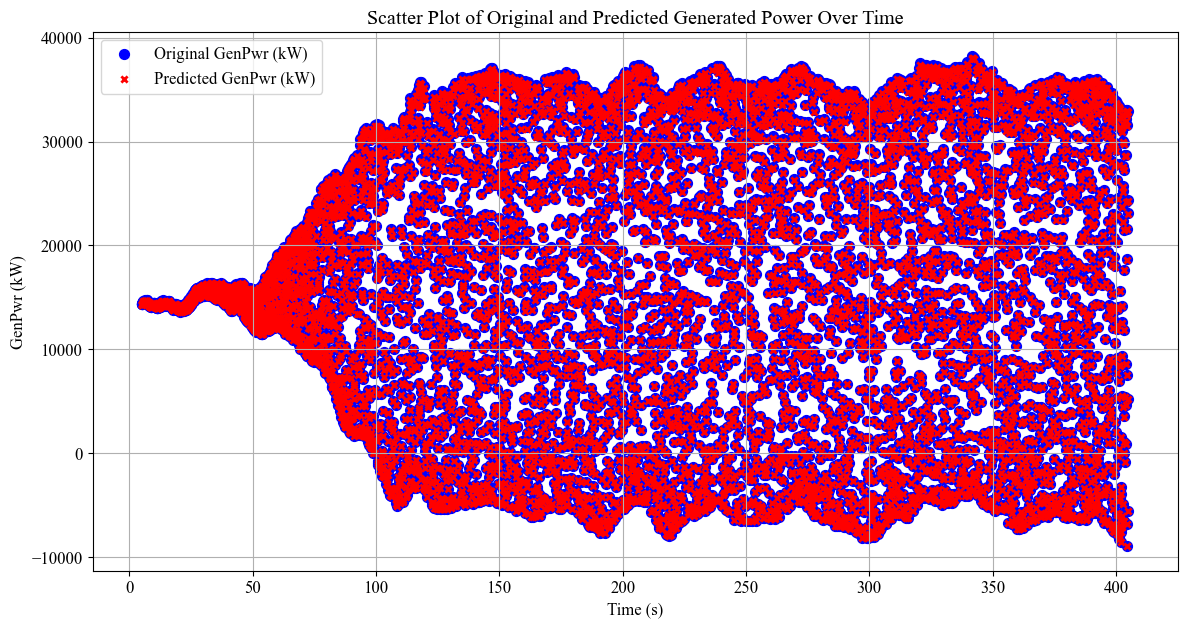

In [21]:
# Sort the time and corresponding y-values
sorted_indices = df['Time_[s]'].iloc[test_indices].argsort()
sorted_time = df['Time_[s]'].iloc[test_indices].iloc[sorted_indices]
sorted_y_test = y_test[sorted_indices]
sorted_y_pred = y_pred[sorted_indices]

# Plot the original power as a line and the predicted power as scatter points with time as the x-axis
plt.figure(figsize=(14, 7))
plt.scatter(sorted_time, sorted_y_test, label='Original GenPwr (kW)', color='b', marker='o', s=50)
plt.scatter(sorted_time, sorted_y_pred, label='Predicted GenPwr (kW)', color='r', marker='x', s=20)
plt.xlabel('Time (s)')
plt.ylabel('GenPwr (kW)')
plt.title('Scatter Plot of Original and Predicted Generated Power Over Time')
plt.legend()
plt.grid(True)
plt.show()

In [14]:
# Save the model to a file in the native Keras format
# model.save('project_folder/Wind/Surrogate models/5MW_TLP_DLL_WTurb_WavesIrr_WavesMulti.keras')

In [15]:
# # Load the model from the file
# loaded_model = tf.keras.models.load_model('project_folder/Wind/Surrogate models/5MW_TLP_DLL_WTurb_WavesIrr_WavesMulti.keras')
# # Verify that the model was loaded correctly
# loaded_model.summary()

# LSTM

In [35]:
# Extract input variables (X) and output variable (y)
# Exclude the time column from the input features
X = df[top_3_columns].values
y = df['GenPwr_[kW]'].values

# Perform train-test split
X_train_val, X_test, y_train_val, y_test, train_val_indices, test_indices = train_test_split(X, y, df.index, test_size=0.2, random_state=42)

# Perform train-validation split
X_train, X_val, y_train, y_val, train_indices, val_indices = train_test_split(X_train_val, y_train_val, train_val_indices, test_size=0.25, random_state=42)

# Normalize the input data
scaler = StandardScaler()
X_train_normalized = scaler.fit_transform(X_train)
X_val_normalized = scaler.transform(X_val)
X_test_normalized = scaler.transform(X_test)

# Reshape the input data for LSTM
X_train_normalized = X_train_normalized.reshape((X_train_normalized.shape[0], 1, X_train_normalized.shape[1]))
X_val_normalized = X_val_normalized.reshape((X_val_normalized.shape[0], 1, X_val_normalized.shape[1]))
X_test_normalized = X_test_normalized.reshape((X_test_normalized.shape[0], 1, X_test_normalized.shape[1]))

# Define the LSTM neural network architecture with dropout and regularization
model = Sequential([
    Input(shape=(X_train_normalized.shape[1], X_train_normalized.shape[2])),
    LSTM(128, activation='relu', return_sequences=True, kernel_regularizer=l2(0.001)),
    Dropout(0.2),
    LSTM(64, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.2),
    Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
    Dense(1)
])

# Define the LSTM neural network architecture with regularization
model = Sequential([
    Input(shape=(X_train_normalized.shape[1], X_train_normalized.shape[2])),
    LSTM(128, activation='relu', return_sequences=True, kernel_regularizer=l2(0.001)),
    LSTM(64, activation='relu', kernel_regularizer=l2(0.001)),
    Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
    Dense(1)
])

# Compile the model with a lower learning rate and gradient clipping
optimizer = Adam(learning_rate=1e-4, clipnorm=1.0)
model.compile(optimizer=optimizer, loss='mse')

# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

# Train the model with callbacks
history = model.fit(X_train_normalized, y_train, epochs=200, batch_size=32, validation_data=(X_val_normalized, y_val), callbacks=[early_stopping, reduce_lr])
# Evaluate the model on the test set
test_loss = model.evaluate(X_test_normalized, y_test)
print(f"Test Loss: {test_loss}")

Epoch 1/200
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 395863424.0000 - val_loss: 396209632.0000 - learning_rate: 1.0000e-04
Epoch 2/200
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 392734688.0000 - val_loss: 392919648.0000 - learning_rate: 1.0000e-04
Epoch 3/200
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 390223200.0000 - val_loss: 379926112.0000 - learning_rate: 1.0000e-04
Epoch 4/200
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 369546496.0000 - val_loss: 346628512.0000 - learning_rate: 1.0000e-04
Epoch 5/200
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 329799616.0000 - val_loss: 283214624.0000 - learning_rate: 1.0000e-04
Epoch 6/200
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 261017616.0000 - val_loss: 188525168.0000 - learning_rate: 1.0000e-04
Epoch 7/200
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 162451584.0000 - val_loss: 89562328.0000 - learning_rate: 1.0000e-04
Epoch 8/200
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 74653960.0000 - val_los

In [36]:
# Make predictions on the testing set
y_pred = model.predict(X_test_normalized).flatten()

# Calculate error metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")

251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 696us/step
Mean Absolute Error (MAE): 1.3186463543275895
Mean Squared Error (MSE): 3.395923121199571
Root Mean Squared Error (RMSE): 1.8428030608829504


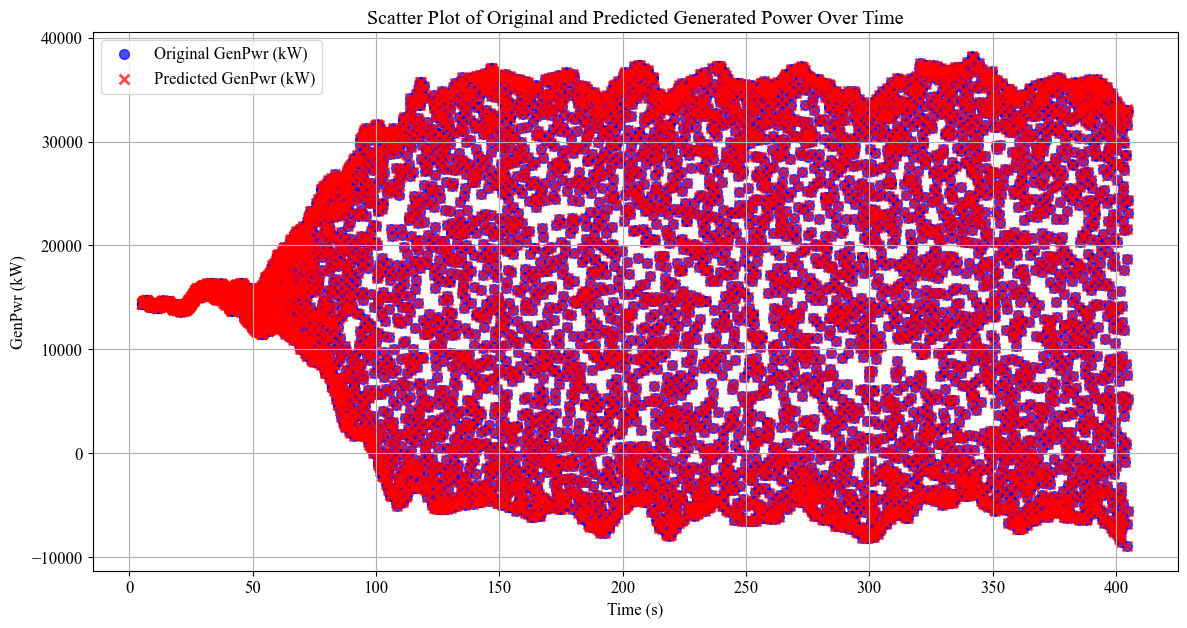

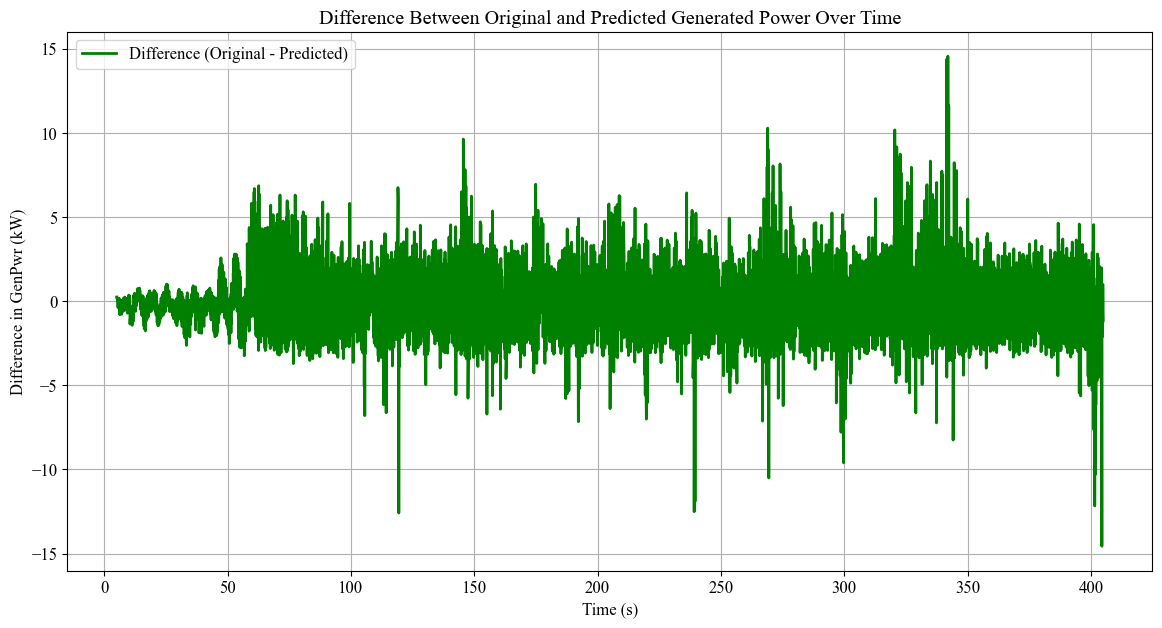

In [48]:
# Sort the time and corresponding y-values
sorted_indices = df['Time_[s]'].iloc[test_indices].argsort()
sorted_time = df['Time_[s]'].iloc[test_indices].iloc[sorted_indices]
sorted_y_test = y_test[sorted_indices]
sorted_y_pred = y_pred[sorted_indices]

# Calculate the difference between the test and predicted values
difference = sorted_y_test - sorted_y_pred

# Plot the original power and the predicted power as scatter points with time as the x-axis
plt.figure(figsize=(14, 7))
plt.scatter(sorted_time, sorted_y_test, label='Original GenPwr (kW)', color='b', marker='o', s=50, alpha=0.7)
plt.scatter(sorted_time, sorted_y_pred, label='Predicted GenPwr (kW)', color='r', marker='x', s=50, alpha=0.7)
plt.xlabel('Time (s)')
plt.ylabel('GenPwr (kW)')
plt.title('Scatter Plot of Original and Predicted Generated Power Over Time')
plt.legend()
plt.grid(True)
plt.show()

# Plot the difference between the test and predicted values
plt.figure(figsize=(14, 7))
plt.plot(sorted_time, difference, label='Difference (Original - Predicted)', color='g', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Difference in GenPwr (kW)')
plt.title('Difference Between Original and Predicted Generated Power Over Time')
plt.legend()
plt.grid(True)
plt.show()

In [57]:
# model.save('project_folder/Wind/Surrogate models/IEA-15MW.keras')